In [1]:
import lambda_css

x = lambda_css.LambdaCSS.get_lCSS({'lemma' : True, 'deprel': False})
y = lambda_css.LambdaCSS.get_lCSS({'lemma' : True, 'deprel': False})
z = lambda_css.LambdaCSS.get_lCSS({'lemma' : True})

print(f'types : {type(x)}, {type(y)}, {type(z)}')
print(f'ids : {id(x)}, {id(y)}, {id(z)}')
print(f'xy', x == y)
print(f'xz', x == z)
print(f'yz', z == y)
print('t xy', type(x) == type(y))
print('t xz', type(x) == type(z))
print('t yz', type(z) == type(y))
print(x)
print(y)
print(z)


C:\Users\lionbouton\Code\phd_code\lambda_css\src\lambda_css\lambdacss.py:235: SyntaxWarning: invalid escape sequence '\d'
  if re.match('\d+', x)
C:\Users\lionbouton\Code\phd_code\lambda_css\src\lambda_css\lambdacss.py:268: SyntaxWarning: invalid escape sequence '\d'
  if re.match('\d+', x)


types : <class 'type'>, <class 'type'>, <class 'type'>
ids : 2092076556912, 2092076556912, 2092084905232
xy True
xz False
yz False
t xy True
t xz True
t yz True
<class 'lambda_css.lambdacss.LambdaCSS_deprel_False_lemma_True'>
<class 'lambda_css.lambdacss.LambdaCSS_deprel_False_lemma_True'>
<class 'lambda_css.lambdacss.LambdaCSS_lemma_True'>


In [ ]:
from a import data2score_pipeline
import lambda_css
import mwe_lexicon
import cupt_parser
import lambda_css_lexicon
import mwe_lexicon
import lambda_css_utils
import oa_indices
import pandas as pd
import os

res = []
parseme_path = 'data/parseme'


langs = [
	'DE', 
	# 'EL', 
	# 'EU', 
	# 'FR',
	# 'FR_sequoia', 
	# 'GA', 
	# 'HE', 
	# 'IT', 
	# 'PL', 
	# 'PT', 
	# 'RO', 
	# 'SV', 
	# 'TR', 
	# 'TR2', 
	# 'ZH', 
	# 'Multi'
]

seq_rep_fs = mwe_lexicon.disc_fs
entry_type = {
	('{lem, dep}-css', 'inf') : lambda_css.LambdaCSS_spec({'lemma' : True, 'deprel': False}),
	# ('{lem, }-css', 'inf') : lambda_css.LambdaCSS.get_lCSS({'lemma' : True}),
	# ('contiguous', '0') : mwe_lexicon.Seq_rep_spec(['lemma'], mwe_lexicon.disc0),
	('lemma', '1') : mwe_lexicon.Seq_rep_spec(['lemma'], mwe_lexicon.disc_lemma1),
	# ('lemma', '2') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_lemma2),
	# ('lemma', '3') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_lemma3),
	# ('lemma', 'inf') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_lemma0),
	# ('upos', '1') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_pos1),
	# ('upos', '2') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_pos2),
	# ('upos', '3') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_pos3),
	# ('upos', 'inf') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_pos0),
	# ('*', '1') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_1),
	# ('*', '2') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_2),
	# ('*', '3') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_3),
	# ('*', 'inf') : mwe_lexicon.Seq_rep.concretize(['lemma'], mwe_lexicon.disc_0),
}



for lang in langs:
	for entry_type_k, entry_type_v in entry_type.items():
		# try:
			TT_train, df_train = cupt_parser.setup_data(
				f'{parseme_path}/1.2/{lang}/traindev.cupt',
			)

			TT_test, df_test = cupt_parser.setup_data(
				f'{parseme_path}/1.2/{lang}/test.cupt'
			)
			truth = cupt_parser.get_mwes(df_test)

			# if isinstance(entry_type_v, type) and issubclass(entry_type_v, lambda_css.LambdaCSS):
			if issubclass(type(entry_type_v), lambda_css.LambdaCSS_spec):
				if os.path.exists('data/lexicons/test2.json'):
					lex = mwe_lexicon.MWE_lexicon.from_json('data/lexicons/test2.json')
				else:
					entry_type = lambda_css_lexicon.LCSSAdapter(entry_type_v)

					# lf = mwe_lexicon.Lexicon_formalism(entry_type)
					# # mwe_lexicon.MWE_lexicon
					lex = mwe_lexicon.MWE_lexicon(entry_type.instantiate(TT_train), entry_type)
					# lex = mwe_lexicon.MWE_lexicon(TT_train, entry_type)
					# lex.to_json('data/lexicons/test2.json')
				pred = lex.match(df_test)
			if issubclass(type(entry_type_v), mwe_lexicon.Seq_rep_spec):
				if os.path.exists('data/lexicons/test.json'):
					# lex = mwe_lexicon.MWE_lexicon.unpickle('data/lexicons/test.pkl')
					lex = mwe_lexicon.MWE_lexicon.from_json('data/lexicons/test.json')
				else:
					test_sorted_columns = lambda_css_utils.sort_column(df_test)
					entry_type = mwe_lexicon.SeqRepAdapter(entry_type_v)
					# lf = mwe_lexicon.Lexicon_formalism(
					# 	entry_type
					# )
					lex = mwe_lexicon.MWE_lexicon(entry_type.instantiate(df_train), entry_type)
					# lex = mwe_lexicon.MWE_lexicon(df_train, entry_type)
					# lex = lf.instantiate(df_train)
					# lex.to_json('data/lexicons/test.json')
					# lex.pickle('data/lexicons/test.pkl')
				pred = lex.match(df_test, test_sorted_columns)

			# if issubclass(entry_type_v, lambda_css.LambdaCSS):
			# 	formalism = mwe_lexicon.Lexicon_formalism.concretize(
			# 		entry_type_v,
			# 		lambda_css_lexicon.extract_lcss_lexicon,
			# 		lambda_css_lexicon.lexicon_matches_in_sentences
			# 	)
			# 	lex = formalism.instantiate(TT_train)
			# 	pred = lex.match(df_test)
			# if issubclass(entry_type_v, mwe_lexicon.Seq_rep):
			# 	test_sorted_columns = lambda_css_utils.sort_column(df_test)

			# 	# if data/lexicons/test.pkl exists, load it instead of instantiating a new lexicon
			# 	if os.path.exists('data/lexicons/test.pkl'):
			# 		formalism = mwe_lexicon.Lexicon_formalism.concretize(
			# 			entry_type_v,
			# 			mwe_lexicon.MWE_lexicon.unpickle,
			# 			mwe_lexicon.SeqRep_match
			# 		)
			# 		with open('data/lexicons/test.pkl', 'rb') as f:
			# 			# f.read()
			# 			lex = formalism.instantiate(f.read())
			# 	else:
			# 		formalism = mwe_lexicon.Lexicon_formalism.concretize(
			# 			entry_type_v,
			# 			mwe_lexicon.extract_pattern_from_data,
			# 			mwe_lexicon.SeqRep_match
			# 		)

			# 		lex = formalism.instantiate(df_train)
			# 		lex.pickle('data/lexicons/test.pkl')

			# 	pred = lex.match(df_test, test_sorted_columns)
			res.append(
				{
					'formalism' : entry_type_k[0],
					'size': entry_type_k[1],
					'lang': lang
				} | 
				oa_indices.full_eval(truth, pred)
			)
			# print(lang, res[lang])
		# except Exception as e:
		# 	print(lang, e)

traindev_vs_test = pd.DataFrame.from_records(res)

C:\Users\lionbouton\Code\phd_code\lambda_css\src\lambda_css\lambdacss.py:230: SyntaxWarning: invalid escape sequence '\d'
  if re.match('\d+', x)
C:\Users\lionbouton\Code\phd_code\lambda_css\src\lambda_css\lambdacss.py:263: SyntaxWarning: invalid escape sequence '\d'
  if re.match('\d+', x)


In [8]:
traindev_vs_test

,formalism,size,lang,p,r,f,richness,N1,normalize_r,H,...,G_21,O,E_x,E_mcl,E_prime,E_var,1/S,exp_minus_S,s_p_val,zipf_s_n
0,"{lem, dep}-css",inf,DE,0.878049,0.567961,0.689757,264.0,177.939731,0.564103,7.475245,...,0.073023,0.714355,0.713269,0.942504,0.642531,0.818464,1.391178,0.487329,0.0001,"(0.7860211748831782, 488.8438909159073, 0.328)"
1,lemma,1,DE,0.898592,0.387136,0.541137,172.0,113.891583,0.539185,6.831517,...,0.079861,0.710651,0.708959,0.928856,0.627925,0.806379,1.320193,0.468853,0.0032,"(0.8534112847919959, 422.121242465395, 0.5348)"


In [10]:
import mwe_lexicon
x = mwe_lexicon.Seq_rep_spec(['lemma'], mwe_lexicon.disc_lemma1)

# get the class that x is bound to, here it's Seq_rep

issubclass(type(x), mwe_lexicon.Seq_rep_spec)


True

In [ ]:
traindev_vs_test

,formalism,size,lang,p,r,f,richness,N1,normalize_r,H,...,G_21,O,E_x,E_mcl,E_prime,E_var,1/S,exp_minus_S,s_p_val,zipf_s_n
0,lemma,1,DE,0.898592,0.387136,0.541137,172.0,113.891583,0.539185,6.831517,...,0.079861,0.710651,0.708959,0.928856,0.627925,0.806379,1.320193,0.468853,0.0024,"(0.8534112847919959, 422.121242465395, 0.5252)"


In [2]:
lex

{([{'lemma': 'arbeiten'}, {'lemma': 'schwarz'}], [('dagegen',)]), ([{'lemma': 'abspielen'}], []), ([{'lemma': 'auszeichnen'}], []), ([{'lemma': 'packen'}, {'lemma': 'aus'}], [()]), ([{'lemma': 'umhüllen'}], []), ([{'lemma': 'kommen'}, {'lemma': 'vor'}], [('ich',)]), ([{'lemma': 'zur'}, {'lemma': 'Verfügung'}, {'lemma': 'stehen'}], [(), ('zu',)]), ([{'lemma': 'ersparen'}, {'lemma': 'bleiben'}], [()]), ([{'lemma': 'zur'}, {'lemma': 'Diskussion'}, {'lemma': 'stehen'}], [(), ()]), ([{'lemma': 'sein'}, {'lemma': 'der'}, {'lemma': 'Rede'}, {'lemma': 'von'}], [(), (), ()]), ([{'lemma': 'nacharbeiten'}], []), ([{'lemma': 'ringen'}, {'lemma': 'mit'}, {'lemma': 'der'}, {'lemma': 'Tod'}], [(), (), ()]), ([{'lemma': 'anfreunden'}], []), ([{'lemma': 'auszuklammern'}], []), ([{'lemma': 'schwarz'}, {'lemma': 'Zahl'}, {'lemma': 'schreiben'}], [(), ()]), ([{'lemma': 'anstehen'}], []), ([{'lemma': 'verständigen'}, {'lemma': 'er|es|sie'}], [()]), ([{'lemma': 'wehren'}, {'lemma': 'er|es|sie'}], [()]), ([{

In [ ]:
# formalism = mwe_lexicon.Lexicon_formalism.concretize(
# 	entry_type[('lemma', '1')],
# 	mwe_lexicon.extract_pattern_from_data,
# 	mwe_lexicon.SeqRep_match
# )

aaa = mwe_lexicon.MWE_lexicon.concretize(
	entry_type[('lemma', '1')],
	mwe_lexicon.SeqRep_match
).unp

# formalism.instantiate_from_string(str(lex))

TypeError: unhashable type: 'list'

In [6]:
xxx = mwe_lexicon.Lexicon_formalism.concretize(
	entry_type[('lemma', '1')],
	mwe_lexicon.MWE_lexicon.unpickle,
	mwe_lexicon.SeqRep_match
).instantiate(lex.pickle())

In [ ]:
xxx

mwe_lexicon.lexicon.MWE_lexicon

In [3]:
import pickle
xxx =pickle.dumps(lex.content, 0)


In [5]:
pickle.load(xxx)

TypeError: file must have 'read' and 'readline' attributes

In [2]:
traindev_vs_test.pivot_table(values='f', index='lang', columns=['formalism', 'size'], sort=False).map(lambda x: round(x, 2))


formalism,lemma
size,1
lang,
DE,0.54


In [38]:
print(traindev_vs_test.pivot_table(values='f', index='lang', columns=['formalism', 'size'], sort=False).map(lambda x: round(x, 2)).to_latex(
	# index=False,
	float_format='%.2f',
	na_rep ='---',
	column_format='ccrccccccccccccc',
	# header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH']
	)
)

\begin{tabular}{ccrccccccccccccc}
\toprule
formalism & {lem, dep}-css & contiguous & \multicolumn{4}{r}{lemma} & \multicolumn{4}{r}{upos} & \multicolumn{4}{r}{*} \\
size &  & 0 & 1 & 2 & 3 & inf & 1 & 2 & 3 & inf & 1 & 2 & 3 & inf \\
lang &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
DE & 0.69 & 0.53 & 0.54 & 0.54 & 0.54 & 0.55 & 0.55 & 0.55 & 0.55 & 0.56 & 0.55 & 0.56 & 0.58 & 0.59 \\
\bottomrule
\end{tabular}



In [6]:
import pandas as pd
pd.DataFrame(res)

,DE,EL,FR,FR_sequoia,GA,HE,IT,PL,PT,SV,TR,TR2,ZH
p,0.875969,0.641487,0.788129,0.850649,0.047414,0.043520,0.675297,0.941349,0.872460,0.870343,0.650099,0.642269,0.090671
r,0.548544,0.549281,0.703458,0.670077,0.100917,0.268390,0.606589,0.715985,0.612035,0.602683,0.568202,0.609904,0.572519
f,0.674627,0.591814,0.743390,0.749642,0.064516,0.074896,0.639102,0.813345,0.719404,0.712195,0.606398,0.625668,0.156549
richness,251.000000,309.000000,373.000000,317.000000,17.000000,100.000000,304.000000,359.000000,423.000000,209.000000,318.000000,323.000000,232.000000
N1,167.608171,229.491462,200.640785,221.899132,13.341717,91.844105,206.426570,214.769682,325.026915,153.730195,211.643352,212.420603,126.860348
normalize_r,0.555310,0.577570,0.390167,0.604962,0.386364,0.740741,0.485623,0.372793,0.547219,0.357877,0.486239,0.460114,0.515556
H,7.388949,7.842297,7.648471,7.793760,3.737872,6.521115,7.689485,7.746647,8.344415,7.264257,7.725491,7.730780,6.987097
J,0.926916,0.948115,0.895288,0.938065,0.914473,0.981526,0.932293,0.912676,0.956433,0.942509,0.929340,0.927465,0.889172
e10,0.667762,0.742691,0.537911,0.699997,0.784807,0.918441,0.679035,0.598244,0.768385,0.735551,0.665545,0.657649,0.546812
e21,0.420324,0.616517,0.444312,0.482979,0.843656,0.906092,0.582683,0.572447,0.719530,0.742979,0.601825,0.602583,0.401874


In [ ]:
import pandas as pd
from a import data_diversity_score

train_diversity = {}
parseme_path = 'data/parseme'

for lang in ['DE', 'EL', 'EU', 'FR', 'FR_sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'RO', 'SV', 'TR', 'TR2', 'ZH']:
	try:
		train_diversity[lang] = data_diversity_score(
			f'{parseme_path}/1.2/{lang}/train.cupt'
		)
		# print(lang, res_diversity[lang])
	except Exception as e:
		pass
		# print(lang, e)
		
pd.DataFrame(train_diversity)

In [1]:
import pandas as pd
from a import data_diversity_score

test_diversity = {}
parseme_path = 'data/parseme'

for lang in ['DE', 'EL', 'EU', 'FR', 'FR_sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'RO', 'SV', 'TR', 'TR2', 'ZH']:
	try:
		test_diversity[lang] = data_diversity_score(
			f'{parseme_path}/1.2/{lang}/test.cupt'
		)
		# print(lang, test_diversity[lang])
	except Exception as e:
		pass
		# print(lang, e)
pd.DataFrame(test_diversity)


,DE,EL,FR,FR_sequoia,GA,HE,IT,PL,PT,SV,TR,TR2,ZH
richness,585.0,682.0,712.0,564.0,310.0,443.0,638.0,689.0,815.0,495.0,719.0,660.0,551.0
N1,442.469342,542.997303,418.814747,431.202765,244.730774,417.732186,463.460339,428.157651,650.567887,365.39964,520.43302,461.744614,365.977353
normalize_r,0.709951,0.700205,0.523915,0.721228,0.711009,0.880716,0.618217,0.512268,0.645289,0.510836,0.624674,0.573414,0.701018
H,8.789434,9.084801,8.710168,8.752223,7.935052,8.706434,8.856302,8.741998,9.345556,8.513331,9.023569,8.850951,8.515611
J,0.956174,0.965069,0.919208,0.957621,0.958788,0.990362,0.950511,0.927202,0.966383,0.951074,0.950865,0.944976,0.935174
e10,0.756358,0.796184,0.588223,0.764544,0.789454,0.942962,0.726427,0.621419,0.798243,0.738181,0.723829,0.699613,0.664206
e21,0.433969,0.639499,0.404233,0.499008,0.638779,0.910786,0.570502,0.513819,0.716739,0.692823,0.585863,0.581382,0.381227
e20,0.328236,0.509158,0.237779,0.381514,0.504287,0.858837,0.414428,0.319297,0.572132,0.511429,0.424065,0.406743,0.253213
F10,0.755941,0.795884,0.587644,0.764126,0.788773,0.942833,0.725997,0.620869,0.797995,0.737651,0.723444,0.699157,0.663595
F21,0.432687,0.638833,0.402807,0.497844,0.637297,0.910572,0.569574,0.512681,0.716303,0.691981,0.585066,0.580474,0.379531


In [146]:
#richness
print(pd.DataFrame(test_diversity).loc[['richness']].to_latex(
	index=False,
	float_format='%.0f',
	na_rep ='---',
	column_format='c' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH']
	)
)


\begin{tabular}{ccccccccccccc}
\toprule
DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
585 & 682 & 712 & 564 & 310 & 443 & 638 & 689 & 815 & 495 & 719 & 660 & 551 \\
\bottomrule
\end{tabular}



In [35]:
#richness normalized
print(pd.DataFrame(test_diversity).loc[['normalize_r']].to_latex(
	index=False,
	# float_format='%.2f'.lstrip('0'),
	float_format=lambda x: ('%.2f' % x).lstrip('0'),
	na_rep ='---',
	column_format='c' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH'],
	)
)

\begin{tabular}{ccccccccccccc}
\toprule
DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
.71 & .70 & .52 & .72 & .71 & .88 & .62 & .51 & .65 & .51 & .62 & .57 & .70 \\
\bottomrule
\end{tabular}



In [79]:
import cupt_parser
import oa_indices
import scipy.stats


richness_normalized_by_size = {}
parseme_path = 'data/parseme'

for lang in ['DE', 'EL', 'EU', 'FR', 'FR_sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'RO', 'SV', 'TR', 'TR2', 'ZH']:
	try:
		TT_train, df_data = cupt_parser.setup_data(
			f'{parseme_path}/1.2/{lang}/test.cupt'
		)
	except Exception as e:
		continue
	data = cupt_parser.get_mwes(df_data)
	inline_data = cupt_parser.inline_mwes(data).reset_index()
	
	# r = []
	# for repetition in range(30):
	# 	sample = inline_data.sample(K).assign(n=1).groupby(0).count()['n']
	nb_sentences = len(data.reset_index()['sentence_id'].unique())
	richness_normalized_by_size[lang] = {'': oa_indices.Na(0, inline_data.assign(n=1).groupby(0).count()['n']) / nb_sentences}
		

pd.DataFrame(richness_normalized_by_size)


,DE,EL,FR,FR_sequoia,GA,HE,IT,PL,PT,SV,TR,TR2,ZH
,0.861561,0.810939,0.61645,1.951557,0.959752,0.982262,0.812739,0.590909,0.728329,0.643693,0.792723,0.727674,0.867717


In [81]:
#richness normalzed by size
print(pd.DataFrame(richness_normalized_by_size).to_latex(
	# index=False,
	# float_format='%.2f'.lstrip('0'),
	float_format=lambda x: ('%.2f' % x).lstrip('0'),
	na_rep ='---',
	column_format='l|'+'c' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH'],
	)
)

\begin{tabular}{l|ccccccccccccc}
\toprule
 & DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
 & .86 & .81 & .62 & 1.95 & .96 & .98 & .81 & .59 & .73 & .64 & .79 & .73 & .87 \\
\bottomrule
\end{tabular}



In [77]:
import cupt_parser
import oa_indices
import scipy.stats


controlled_richness = {}
parseme_path = 'data/parseme'
K = 150



for lang in ['DE', 'EL', 'EU', 'FR', 'FR_sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'RO', 'SV', 'TR', 'TR2', 'ZH']:
	try:
		TT_train, df_data = cupt_parser.setup_data(
			f'{parseme_path}/1.2/{lang}/test.cupt'
		)
	except Exception as e:
		continue
	data = cupt_parser.get_mwes(df_data)
	inline_data = cupt_parser.inline_mwes(data).reset_index()
	
	r = []
	for repetition in range(30):
		sample = inline_data.sample(K).assign(n=1).groupby(0).count()['n']
		r.append(oa_indices.Na(0, sample) / K)
		
	desc = scipy.stats.describe(r)
	controlled_richness[lang] = {'mean r bar': desc.mean ,'std': desc.variance ** 0.5}

pd.DataFrame(controlled_richness)


,DE,EL,FR,FR_sequoia,GA,HE,IT,PL,PT,SV,TR,TR2,ZH
mean r bar,0.885111,0.897556,0.802000,0.889111,0.834000,0.956667,0.864889,0.828222,0.908667,0.838889,0.871333,0.852000,0.829333
std,0.023921,0.021334,0.022567,0.021262,0.026047,0.013646,0.028118,0.026126,0.026386,0.028343,0.033683,0.027482,0.027269


In [78]:
#richness controlled
print(pd.DataFrame(controlled_richness).to_latex(
	# index=False,
	# float_format='%.2f'.lstrip('0'),
	float_format=lambda x: ('%.2f' % x).lstrip('0'),
	na_rep ='---',
	column_format='l|'+'C' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH'],
	)
)

\begin{tabular}{l|CCCCCCCCCCCCC}
\toprule
 & DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
mean r bar & .89 & .90 & .80 & .89 & .83 & .96 & .86 & .83 & .91 & .84 & .87 & .85 & .83 \\
std & .02 & .02 & .02 & .02 & .03 & .01 & .03 & .03 & .03 & .03 & .03 & .03 & .03 \\
\bottomrule
\end{tabular}



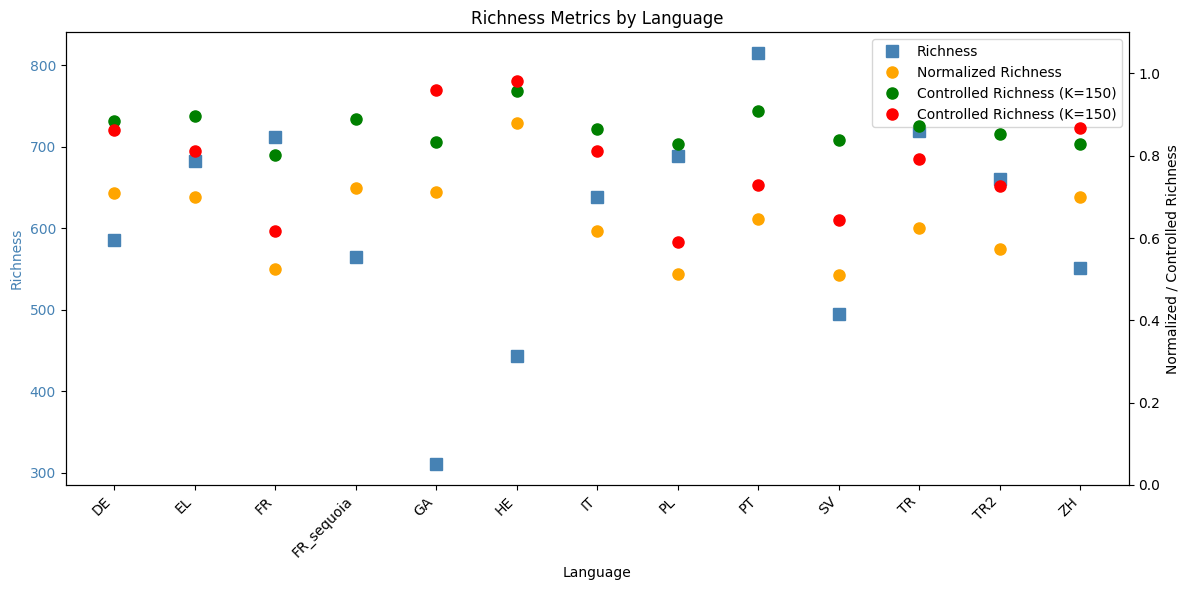

In [150]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

languages = list(test_diversity.keys())
x = range(len(languages))

# Left axis - Richness
richness = [test_diversity[lang]['richness'] for lang in languages]
ax1.plot(x, richness, 's', label='Richness', color='steelblue',  markersize=8)
ax1.set_xlabel('Language')
ax1.set_ylabel('Richness', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(languages, rotation=45, ha='right')

# Right axis - Normalized and Controlled Richness
ax2 = ax1.twinx()
normalized_r = [test_diversity[lang]['normalize_r'] for lang in languages]
controlled_r = [controlled_richness[lang]['mean r bar'] for lang in languages]
normalized_r2= [richness_normalized_by_size[lang][''] for lang in languages]

ax2.plot(x, normalized_r, 'o', label='Normalized Richness', color='orange', markersize=8)
ax2.plot(x, controlled_r, 'o', label='Controlled Richness (K=150)', color='green', markersize=8)
ax2.plot(x, normalized_r2, 'o', label='Controlled Richness (K=150)', color='red', markersize=8)
ax2.set_ylabel('Normalized / Controlled Richness', color='black')
ax2.set_ylim(0, 1.1)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Richness Metrics by Language')
plt.tight_layout()
plt.show()

In [82]:
pd.DataFrame(test_diversity)

,DE,EL,FR,FR_sequoia,GA,HE,IT,PL,PT,SV,TR,TR2,ZH
richness,585.0,682.0,712.0,564.0,310.0,443.0,638.0,689.0,815.0,495.0,719.0,660.0,551.0
N1,442.469342,542.997303,418.814747,431.202765,244.730774,417.732186,463.460339,428.157651,650.567887,365.39964,520.43302,461.744614,365.977353
normalize_r,0.709951,0.700205,0.523915,0.721228,0.711009,0.880716,0.618217,0.512268,0.645289,0.510836,0.624674,0.573414,0.701018
H,8.789434,9.084801,8.710168,8.752223,7.935052,8.706434,8.856302,8.741998,9.345556,8.513331,9.023569,8.850951,8.515611
J,0.956174,0.965069,0.919208,0.957621,0.958788,0.990362,0.950511,0.927202,0.966383,0.951074,0.950865,0.944976,0.935174
e10,0.756358,0.796184,0.588223,0.764544,0.789454,0.942962,0.726427,0.621419,0.798243,0.738181,0.723829,0.699613,0.664206
e21,0.433969,0.639499,0.404233,0.499008,0.638779,0.910786,0.570502,0.513819,0.716739,0.692823,0.585863,0.581382,0.381227
e20,0.328236,0.509158,0.237779,0.381514,0.504287,0.858837,0.414428,0.319297,0.572132,0.511429,0.424065,0.406743,0.253213
F10,0.755941,0.795884,0.587644,0.764126,0.788773,0.942833,0.725997,0.620869,0.797995,0.737651,0.723444,0.699157,0.663595
F21,0.432687,0.638833,0.402807,0.497844,0.637297,0.910572,0.569574,0.512681,0.716303,0.691981,0.585066,0.580474,0.379531


In [114]:
#balance shannon
print(pd.DataFrame(test_diversity).loc[['H', 'J', 'N1']].to_latex(
	# index=False,
	float_format='%.2f',
	na_rep ='---',
	column_format='l|'+'C' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH']
	)
)

\begin{tabular}{l|CCCCCCCCCCCCC}
\toprule
 & DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
H & 8.79 & 9.08 & 8.71 & 8.75 & 7.94 & 8.71 & 8.86 & 8.74 & 9.35 & 8.51 & 9.02 & 8.85 & 8.52 \\
J & 0.96 & 0.97 & 0.92 & 0.96 & 0.96 & 0.99 & 0.95 & 0.93 & 0.97 & 0.95 & 0.95 & 0.94 & 0.94 \\
N1 & 442.47 & 543.00 & 418.81 & 431.20 & 244.73 & 417.73 & 463.46 & 428.16 & 650.57 & 365.40 & 520.43 & 461.74 & 365.98 \\
\bottomrule
\end{tabular}



In [ ]:
#balance N1
print(pd.DataFrame(test_diversity).loc[['N1']].to_latex(
	# index=False,
	float_format='%.2f',
	na_rep ='---',
	column_format='l|'+'C' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH']
	)
)

\begin{tabular}{l|CCCCCCCCCCCCC}
\toprule
 & DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
N1 & 442.47 & 543.00 & 418.81 & 431.20 & 244.73 & 417.73 & 463.46 & 428.16 & 650.57 & 365.40 & 520.43 & 461.74 & 365.98 \\
\bottomrule
\end{tabular}



In [ ]:
#balance E F
print(pd.DataFrame(test_diversity).loc[['e10', 'e21', 'F10', 'F21']].to_latex(
	# index=False,
	float_format='%.2f',
	na_rep ='---',
	column_format='l|'+'C' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH']
	)
)

\begin{tabular}{l|CCCCCCCCCCCCC}
\toprule
 & DE & EL & FR & Sequoia & GA & HE & IT & PL & PT & SV & TR & TR* & ZH \\
\midrule
e10 & 0.76 & 0.80 & 0.59 & 0.76 & 0.79 & 0.94 & 0.73 & 0.62 & 0.80 & 0.74 & 0.72 & 0.70 & 0.66 \\
e21 & 0.43 & 0.64 & 0.40 & 0.50 & 0.64 & 0.91 & 0.57 & 0.51 & 0.72 & 0.69 & 0.59 & 0.58 & 0.38 \\
F10 & 0.76 & 0.80 & 0.59 & 0.76 & 0.79 & 0.94 & 0.73 & 0.62 & 0.80 & 0.74 & 0.72 & 0.70 & 0.66 \\
F21 & 0.43 & 0.64 & 0.40 & 0.50 & 0.64 & 0.91 & 0.57 & 0.51 & 0.72 & 0.69 & 0.59 & 0.58 & 0.38 \\
\bottomrule
\end{tabular}



In [ ]:
#balance N1
print(pd.DataFrame(test_diversity).loc[['e10', 'e21', 'F10', 'F21']].to_latex(
	# index=False,
	float_format='%.2f',
	na_rep ='---',
	column_format='l|'+'C' * len(test_diversity),
	header=['DE', 'EL', 'FR', 'Sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'SV', 'TR', 'TR*', 'ZH']
	)
)

In [ ]:
import pandas as pd
from a import data_diversity_score

test_diversity = {}
parseme_path = 'data/parseme'

for lang in ['DE', 'EL', 'EU', 'FR', 'FR_sequoia', 'GA', 'HE', 'IT', 'PL', 'PT', 'RO', 'SV', 'TR', 'TR2', 'ZH']:
	try:
		test_diversity[lang] = data_diversity_score(
			f'{parseme_path}/1.2/{lang}/test.cupt'
		)
		# print(lang, test_diversity[lang])
	except Exception as e:
		pass
		# print(lang, e)
pd.DataFrame(test_diversity)

In [6]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import zipfian
def zipf_s_n(p):
	counts = p.sort_values(ascending=False).values
	y_data = counts / np.sum(counts)

	def objective(params):
		s, n = params
		n = int(round(n)) 
		padded_x_data = np.arange(1, n+1)
		padded_y_data = np.concatenate([
			y_data,
			np.zeros(n- len(y_data))
		])
		pmf_vals = zipfian.pmf(padded_x_data, s, n)
		if np.any(np.isnan(pmf_vals)) or np.any(np.isinf(pmf_vals)):
			return np.inf
		return np.sum((pmf_vals - padded_y_data)**2)

	result = minimize(
		objective,
		x0=[1.0, len(p)],  # initial guess
		method='Nelder-Mead',
		bounds=[(0,10), (len(p), 1e6)],
		options={'maxiter': 50}
	)

	# counts = p.sort_values(ascending=False).values
	ranks = np.arange(1, len(y_data) + 1)
	print(ranks, y_data)
	samples = np.repeat(ranks, counts) 

	s, n = result.x
	n = int(round(n))
	null_dist = zipfian.pmf(ranks, s, n)
	ll_obs = np.sum(y_data * np.log(null_dist))
	iterations = 10000
	sim_counts = np.random.multinomial(len(samples), null_dist, size=iterations)
	ll_sim = sim_counts @ np.log(null_dist)
	p_value = np.mean(ll_sim <= ll_obs)
	return s, n, p_value

zipf_s_n(tp_grpby)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 244 245 246 24

(np.float64(0.6677116394042975), 712, np.float64(1.0))

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import zipfian

p = tp_grpby / sum(tp_grpby)
curve_fit(
	lambda x, s, n: zipfian.pmf(x, s, n),
	list(range(1, len(p)+1)),
	p.sort_values(ascending=False),
	bounds=([0.1, len(p)//2], [10, 1e6]),
)

ValueError: array must not contain infs or NaNs

In [ ]:
from scipy.optimize import differential_evolution
from scipy.stats import zipfian
import numpy as np

p = tp_grpby / sum(tp_grpby)
y_data = p.sort_values(ascending=False).values
x_data = np.array(range(1, len(p)+1))

def objective(params):
    s, n = params
    n = int(round(n))
    pmf_vals = zipfian.pmf(x_data, s, n)
    if np.any(np.isnan(pmf_vals)) or np.any(np.isinf(pmf_vals)):
        return 1e10
    return np.sum((pmf_vals - y_data)**2)

result = differential_evolution(
    objective,
    bounds=[(0.1, 10), (len(p), 1e6)],
    seed=42,
    integrality=[False, True]  # n is integer
)

print(f"s = {result.x[0]}, n = {int(result.x[1])}")

In [ ]:
from scipy.optimize import minimize
from scipy.optimize import differential_evolution
from scipy.stats import zipfian
import numpy as np

p = tp_grpby / sum(tp_grpby)
y_data = p.sort_values(ascending=False).values
x_data = np.array(range(1, len(p)+1))

def objective(params):
	s, n = params
	n = int(round(n))  # Force n to be integer
	# print(n)
	padded_x_data = np.arange(1, n+1)
	padded_y_data = np.concatenate([
		y_data,
		np.zeros(n- len(y_data))
	])
	# if n < len(p) or s <= 0:
	#     return np.inf
	pmf_vals = zipfian.pmf(padded_x_data, s, n)
	if np.any(np.isnan(pmf_vals)) or np.any(np.isinf(pmf_vals)):
		return np.inf
	return np.sum((pmf_vals - padded_y_data)**2)

result = minimize(
	objective,
	x0=[1.0, len(p)],  # initial guess
	method='Nelder-Mead',
	bounds=[(0,10), (len(p), 1e6)],
	options={'maxiter': 100}
)

# result = differential_evolution(
#     objective,
#     bounds=[(0.1, 10), (len(p), len(p) * 10)],
#     seed=42,
#     integrality=[False, True],  # n is integer,
# 		maxiter = 10
# )

s_fit, n_predicted = result.x
n_predicted = int(round(n_predicted))
print(f"s = {s_fit}, n = {n_predicted}")

result


s = 0.6677116394042975, n = 712


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.00026234638136758925
             x: [ 6.677e-01  7.120e+02]
           nit: 28
          nfev: 53
 final_simplex: (array([[ 6.677e-01,  7.120e+02],
                       [ 6.676e-01,  7.120e+02],
                       [ 6.678e-01,  7.120e+02]]), array([ 2.623e-04,  2.623e-04,  2.623e-04]))

In [ ]:
from scipy.stats import zipfian, kstest, chisquare
import numpy as np

# After fitting s_fit and n_fit...

# Option 1: Kolmogorov-Smirnov test
# Need to convert your frequency data back to samples
counts = tp_grpby.sort_values(ascending=False).values
ranks = np.arange(1, len(counts) + 1)
samples = np.repeat(ranks, counts)  # Reconstruct samples from frequencies

ks_stat, ks_pvalue = kstest(
    samples, 
    lambda x: zipfian.cdf(x, s_fit, n_predicted)
)
print(f"KS test: statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")

# Option 2: Chi-squared goodness-of-fit test
observed = counts
expected = zipfian.pmf(ranks, s_fit, n_predicted) * sum(counts)

# Filter out bins with expected < 5 (chi-squared assumption)
mask = expected >= 5
chi2_stat, chi2_pvalue = chisquare(observed[mask], expected[mask])
print(f"Chi-squared test: statistic={chi2_stat:.4f}, p-value={chi2_pvalue:.4f}")


KS test: statistic=0.0413, p-value=0.0190


In [113]:
from scipy.stats import zipfian
import numpy as np
from collections import Counter
import pandas as pd


s = 0.5
N = 1000
sample_size = 100

# Generate synthetic Zipfian data
data = zipfian.rvs(s, N, size=100)
data_counts = Counter(data)
n_predicted = len(data_counts)
abondances = pd.Series(sorted(data_counts.values(), reverse=True))


# Estimate s from abondances
s_predricted = oa_indices.zipf_s(abondances / sample_size)

abondances_predicted = zipfian.pmf(range(1, n_predicted+1), s_predricted, n_predicted) * sample_size
# Evaluate fit
sum(abs(abondances_predicted - abondances))

# Expected number of types for sample size


0     3
1     3
2     2
3     2
4     2
     ..
86    1
87    1
88    1
89    1
90    1
Length: 91, dtype: int64


13.93453557462177